In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def perform_eda(file_path):
    """
    Universal EDA (Stops before preprocessing/modeling)

    Works for:
    Iris, Loan, Diabetes, MNIST(CSV), Spam(SMS)

    Usage:
        perform_eda("file.csv")
    """

    try:
        df = pd.read_csv(file_path,encoding="latin1")
    except:
        df = pd.read_csv(file_path)

    print("="*80)
    print("DATASET OVERVIEW")
    print("="*80)
    print("Shape :",df.shape)
    print("\nColumns\n",df.columns.tolist())
    print("\nInfo")
    df.info()
    print("\nFirst 5 Rows")
    print(df.head())
    print("\nSummary")
    print(df.describe(include="all"))
    print("\nMissing Values")
    print(df.isnull().sum())
    print("\nDuplicate Rows :",df.duplicated().sum())

    # ---------- Spam ----------
    if "v1" in df.columns and "v2" in df.columns:
        df=df.drop(columns=[c for c in df.columns if "Unnamed" in c],errors="ignore")
        df.columns=["Label","Message"]
        df["Length"]=df["Message"].str.len()

        #1
        sns.countplot(data=df,x="Label")
        plt.title("Spam vs Ham")
        plt.show()

        #2
        sns.histplot(df["Length"],kde=True)
        plt.title("Message Length Distribution")
        plt.show()

        #3
        sns.boxplot(data=df,x="Label",y="Length")
        plt.title("Message Length Boxplot")
        plt.show()

        #4
        sns.violinplot(data=df,x="Label",y="Length")
        plt.title("Message Length Violin Plot")
        plt.show()

        #5
        stats.probplot(df["Length"],dist="norm",plot=plt)
        plt.title("QQ Plot")
        plt.show()

        #6
        plt.scatter(range(len(df)),df["Length"],s=8)
        plt.title("Length Scatter")
        plt.xlabel("Message Index")
        plt.ylabel("Length")
        plt.show()

        #7
        print(df.groupby("Label")["Length"].describe())
        return

    # ---------- MNIST ----------
    if "label" in df.columns and df.shape[1]==785:

        #1
        sns.countplot(data=df,x="label")
        plt.title("Digit Distribution")
        plt.show()

        #2
        plt.figure(figsize=(12,5))
        for i in range(10):
            plt.subplot(2,5,i+1)
            plt.imshow(df.iloc[i,1:].values.reshape(28,28),cmap="gray")
            plt.title(df.iloc[i,0])
            plt.axis("off")
        plt.tight_layout()
        plt.show()

        pixels=df.iloc[:,1:].values.flatten()

        #3
        sns.histplot(pixels,bins=40)
        plt.title("Pixel Distribution")
        plt.show()

        #4
        sns.boxplot(x=pixels)
        plt.title("Pixel Boxplot")
        plt.show()

        #5
        sns.violinplot(x=pixels)
        plt.title("Pixel Violin Plot")
        plt.show()

        #6
        stats.probplot(pixels[:5000],dist="norm",plot=plt)
        plt.title("Pixel QQ Plot")
        plt.show()

        #7
        print(df["label"].value_counts())
        return

    # Diabetes hint
    if "Outcome" in df.columns:
        cols=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
        print("\nPossible Missing Values Stored as Zero")
        for c in cols:
            if c in df.columns:
                print(f"{c}: {(df[c]==0).sum()}")

    num=df.select_dtypes(include=np.number).columns.tolist()
    cat=df.select_dtypes(exclude=np.number).columns.tolist()

    #1 Histograms
    for c in num:
        sns.histplot(df[c],kde=True,bins=30)
        plt.title(f"Histogram - {c}")
        plt.show()

    #2 Boxplots
    for c in num:
        sns.boxplot(x=df[c])
        plt.title(f"Boxplot - {c}")
        plt.show()

    #3 Violin
    for c in num:
        sns.violinplot(x=df[c])
        plt.title(f"Violin - {c}")
        plt.show()

    #4 Countplots
    for c in cat:
        sns.countplot(data=df,x=c)
        plt.xticks(rotation=45)
        plt.title(f"Countplot - {c}")
        plt.tight_layout()
        plt.show()

    #5 Heatmap
    if len(num)>1:
        sns.heatmap(df[num].corr(),annot=True,cmap="coolwarm",fmt=".2f")
        plt.title("Correlation Heatmap")
        plt.show()

    #6 Pairplot (skip huge datasets)
    if len(num)<=8:
        hue=None
        for h in ["Species","species","Loan_Status","Outcome"]:
            if h in df.columns:
                hue=h
                break
        sns.pairplot(df,hue=hue)
        plt.show()

    #7 QQ Plots
    for c in num:
        stats.probplot(df[c].dropna(),dist="norm",plot=plt)
        plt.title(f"QQ Plot - {c}")
        plt.show()

    print("\nEDA Completed.")


DATASET OVERVIEW
Shape : (5572, 5)

Columns
 ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Info
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB

First 5 Rows
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        

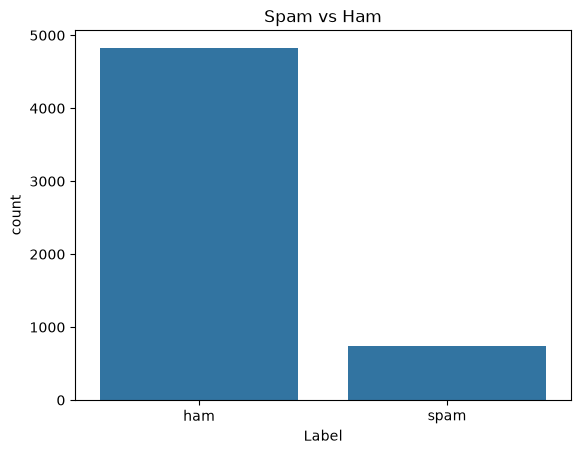

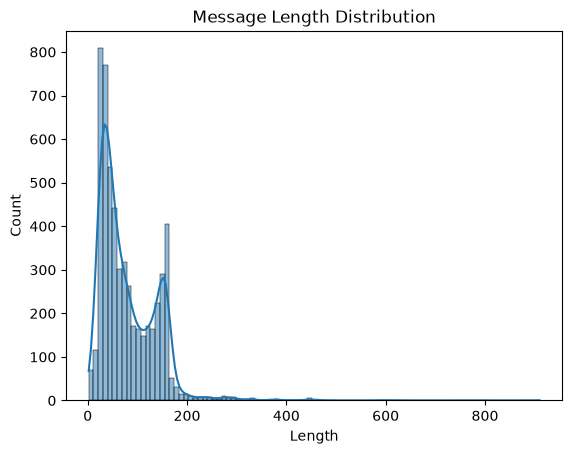

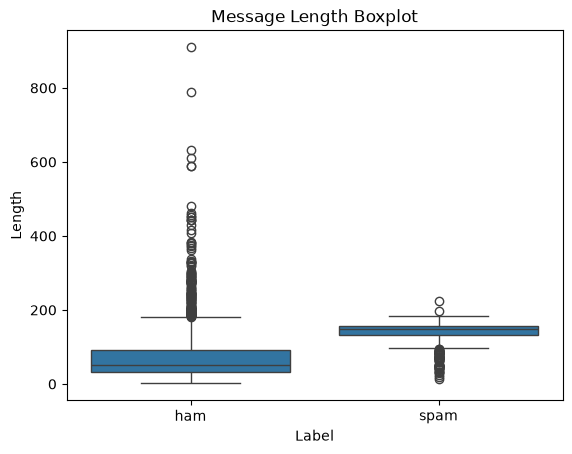

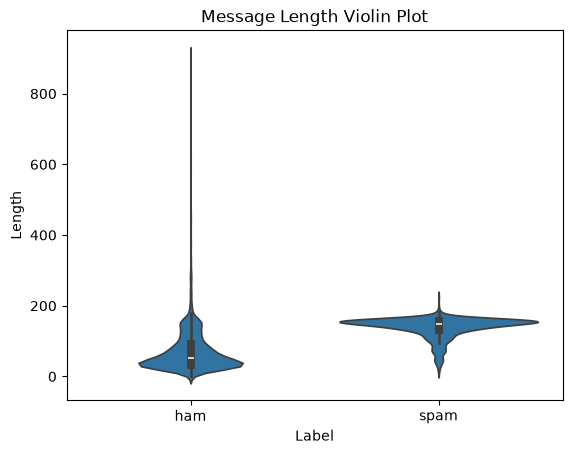

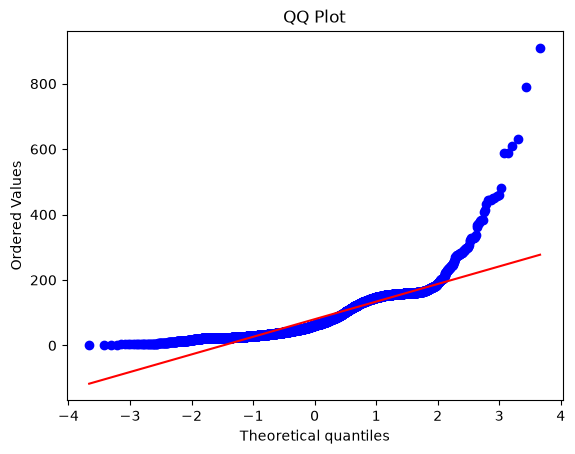

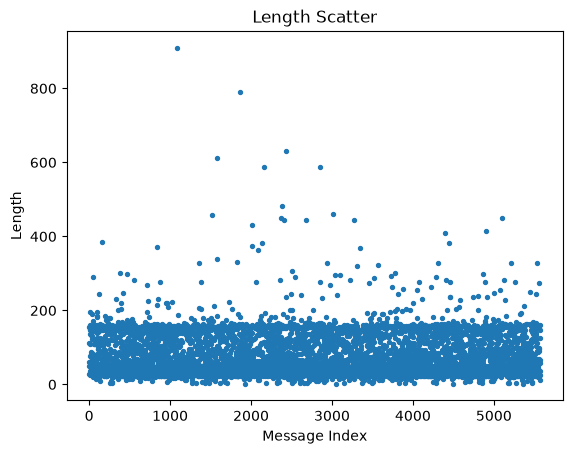

        count        mean        std   min    25%    50%    75%    max
Label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [9]:
perform_eda("spam.csv")